In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import warnings
import os

import gfdl_utils.core as gu
import CM4Xutils
import cftime
import numpy as np
import pandas as pd
import xarray as xr
import xgcm
import xhistogram
import xwmt

import cmocean
import matplotlib.colors as colors
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
plt.rcParams.update({'font.size': 11})

### Load postprocessed model datasets

In [22]:
from common import *
grids = load_datasets()

Inferring Z grid coordinate: depth `z_`
Inferring Z grid coordinate: depth `z_`


In [23]:
fluxes = sum([
    xr.open_dataset(f"../data/interim/CM4Xp125_{exp}_tracer_flux_integrals.nc")
    for exp in ["historical", "ssp585"]
])

In [41]:
source_year = xr.open_dataset("../data/processed/cfc11_sink_to_source_transition_year.nc").year
always_sink = source_year == 2100

### Evolution of Air-Sea CFC Fluxes

/vftmp/Henri.Drake/pid534760/ipykernel_1351982/2457748540.py:53: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(


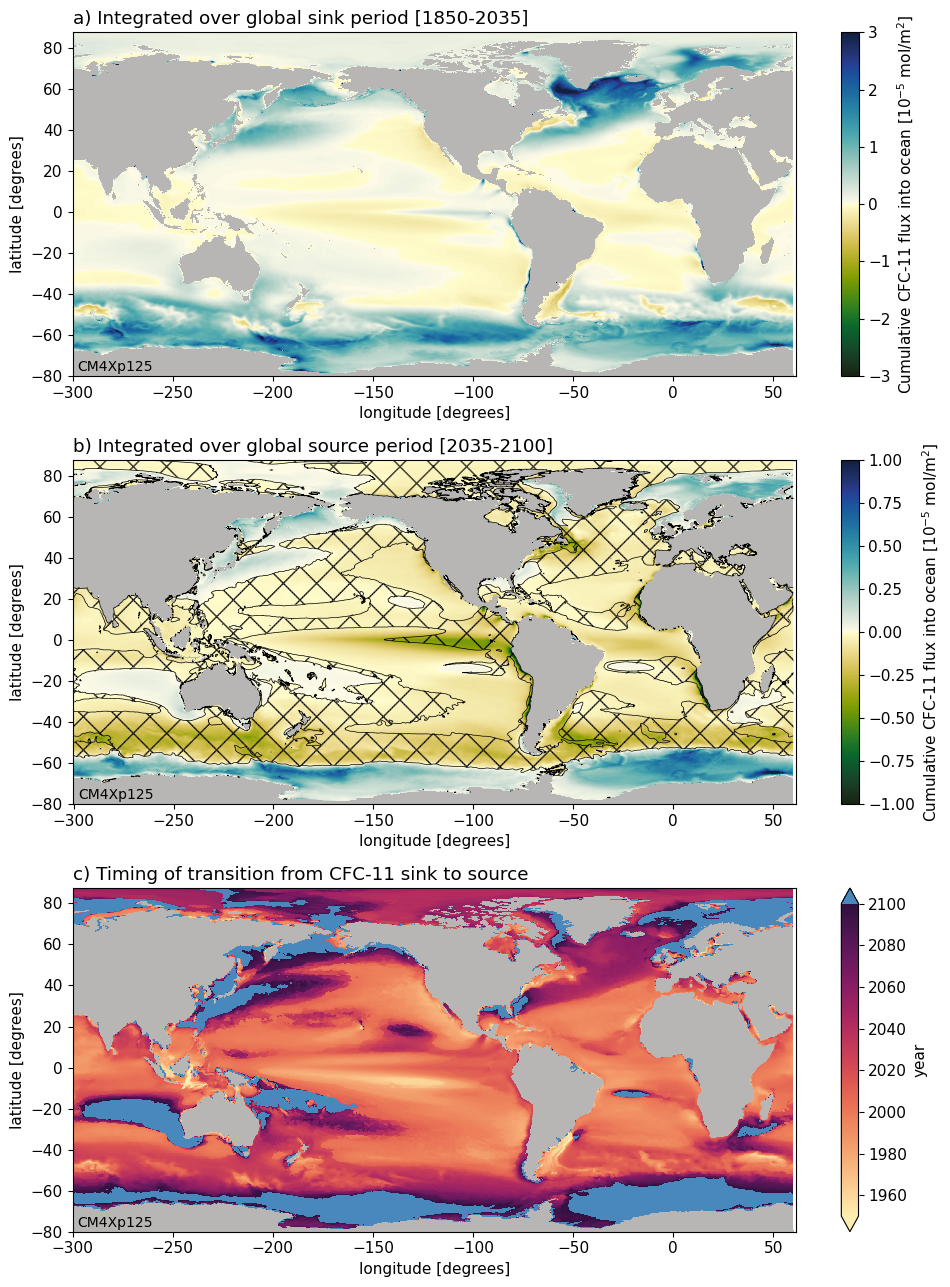

In [42]:
import cmocean
cmap = cmocean.cm.delta_r.copy()
cmap.set_bad(facecolor)

fig, axes = plt.subplots(3,1,figsize=(10,13))

## Sink
plt.sca(axes[0])
fgcfc11_sink = fluxes["fgcfc11_timeint_before"].where(fluxes.deptho.values > 0)
plt.pcolormesh(
    fluxes.geolon_c,
    fluxes.geolat_c,
    fgcfc11_sink*1e5,
    vmin=-3,
    vmax=3,
    cmap=cmap
)
plt.colorbar(label=r"Cumulative CFC-11 flux into ocean [$10^{-5}$ mol/m$^{2}$]")
plt.xlabel("longitude [degrees]")
plt.ylabel("latitude [degrees]")
plt.title("a) Integrated over global sink period [1850-2035]", loc="left")
plt.annotate(
    "CM4Xp125", (-297.5, -79), rotation="horizontal",
    ha="left", va="bottom", color="k", fontsize=10
)
plt.ylim(-80, 87.5)

## Source
plt.sca(axes[1])
fgcfc11_source = fluxes["fgcfc11_timeint_after"].where(fluxes.deptho.values > 0)
plt.pcolormesh(
    fluxes.geolon_c,
    fluxes.geolat_c,
    fgcfc11_source*1e5,
    vmin=-1,
    vmax=1,
    cmap=cmap
)
plt.colorbar(label=r"Cumulative CFC-11 flux into ocean [$10^{-5}$ mol/m$^{2}$]")

sink_to_source = (fluxes['fgcfc11_timeint_before'] > 0) & (fluxes['fgcfc11_timeint_after'] < 0)
plt.contour(
    fluxes.geolon,
    fluxes.geolat,
    sink_to_source,
    levels=[0.5], linestyles="solid", colors="k", linewidths=0.5
)
fgcfc11_source_masked = np.ma.masked_array(
    fgcfc11_source,
    mask=np.logical_not(sink_to_source)
)
N = 8
plt.pcolor(
    fluxes.geolon[N//2::N,N//2::N],
    fluxes.geolat[N//2::N,N//2::N],
    fgcfc11_source_masked[N//2::N,N//2::N],
    hatch='X',
    alpha=0.
)

plt.xlabel("longitude [degrees]")
plt.ylabel("latitude [degrees]")
plt.title("b) Integrated over global source period [2035-2100]", loc="left")
plt.ylim(-80, 87.5)
plt.annotate(
    "CM4Xp125", (-297.5, -79), rotation="horizontal",
    ha="left", va="bottom", color="k", fontsize=10
)

plt.sca(axes[2])
cmap = cmocean.cm.matter.copy()
color_pick = 0.55
cmap.set_extremes(over=cmocean.cm.ice(color_pick))
pc = plt.pcolormesh(
    source_year.geolon,
    source_year.geolat,
    source_year,
    cmap=cmap,
    vmin=1950, vmax=2100,
)
plt.colorbar(pc, label="year", extend="both")
plt.pcolormesh(
    source_year.geolon,
    source_year.geolat,
    always_sink.where(always_sink)*color_pick,
    cmap=cmocean.cm.ice,
    vmin=0, vmax=1
)
plt.pcolormesh(
    source_year.geolon,
    source_year.geolat,
    source_year.deptho.where(source_year.deptho==0) + 1,
    cmap=cmocean.cm.gray,
    vmin=0, vmax=1.3
)

plt.xlabel("longitude [degrees]")
plt.ylabel("latitude [degrees]")
plt.title("c) Timing of transition from CFC-11 sink to source", loc="left")
plt.ylim(-80, 87.5);
plt.annotate(
    "CM4Xp125", (-297.5, -79), rotation="horizontal",
    ha="left", va="bottom", color="k", fontsize=10
)

plt.tight_layout()
plt.savefig("../figures/Fig2_integrated_flux_cfc11.png", dpi=400, bbox_inches="tight")